# Monet-Style Image Generation with DCGAN  
## Deep Learning Specialization — Course 5, Week 5 (Peer-graded Assignment)

In this project, I train a Generative Adversarial Network (GAN) to synthesize new Monet-style images using the Kaggle “GAN – Getting Started” dataset. The goal is to build a well-structured generative model, analyze its behavior during training, and evaluate the realism of generated samples using Kaggle’s MiFID score.


## 1. Problem Description and Dataset

The task is to teach a neural network to create new images that resemble Monet’s paintings.  
Unlike classification or regression, here the model’s goal is to *generate* data from scratch.

The dataset contains 300 Monet-style images, each stored in 256×256 resolution (RGB). These images exhibit distinctive textures, color palettes, and painterly style. These images exhibit distinctive textures, color palettes, and painterly style. Our model must learn these characteristics well enough to produce new images that could plausibly belong to the dataset.

Kaggle evaluates the generated images using **MiFID**, an improved variant of Fréchet Inception Distance that takes both realism and memorization into account.



## 2. Imports and Setup

In this section, I load the main libraries, set a few global constants, and define paths to the Kaggle dataset. This makes the rest of the notebook easier to read and modify.



In [3]:
# -------------------------------------------------------------
# Imports and basic configuration
# -------------------------------------------------------------

import os
import glob
import random
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# I like to check the TensorFlow version to be aware of the environment
print("TensorFlow version:", tf.__version__)

# -------------------------------------------------------------
# Paths to the dataset (local or Kaggle)
# -------------------------------------------------------------

# Local dataset path (your actual folder with data)
local_path = Path("G:/IDL Module 5/Module-5-IDL/data")

# Kaggle dataset path
kaggle_path = Path("/kaggle/input/gan-getting-started")

# Automatically detect environment
if kaggle_path.exists():
    DATA_ROOT = kaggle_path
    print("Running on Kaggle.")
elif local_path.exists():
    DATA_ROOT = local_path
    print("Running locally.")
else:
    raise FileNotFoundError(
        "Dataset not found in: "
        f"\n - {local_path}"
        f"\n - {kaggle_path}"
    )

# Folders inside the dataset
MONET_DIR = DATA_ROOT / "monet_jpg"
PHOTO_DIR = DATA_ROOT / "photo_jpg"

print("Monet directory exists:", MONET_DIR.exists())
print("Photo directory exists:", PHOTO_DIR.exists())

# -------------------------------------------------------------
# Global hyperparameters
# -------------------------------------------------------------

# Image resolution for GAN training
IMG_HEIGHT = 64
IMG_WIDTH = 64
IMG_CHANNELS = 3
IMAGE_SHAPE = (IMG_HEIGHT, IMG_WIDTH, IMG_CHANNELS)

# Size of each batch in the tf.data pipeline
BATCH_SIZE = 64

# Latent dimensionality for the noise vector z
LATENT_DIM = 100

# Number of training epochs
EPOCHS = 50

# Print final config to confirm
print("Image shape:", IMAGE_SHAPE)
print("Batch size:", BATCH_SIZE)
print("Latent dimension:", LATENT_DIM)
print("Epochs:", EPOCHS)



TensorFlow version: 2.20.0
Running locally.
Monet directory exists: True
Photo directory exists: True
Image shape: (64, 64, 3)
Batch size: 64
Latent dimension: 100
Epochs: 50


## 3. Exploratory Data Analysis (EDA)

Before building the GAN, I take a quick look at the dataset to understand how many Monet images are available, what their resolution is, and what the overall visual style looks like. This helps confirm that the preprocessing pipeline and the GAN architecture can be configured appropriately.

Below, I list the dataset structure, inspect a few file paths, check image dimensions, and display sample Monet paintings.


Number of Monet images: 300
Number of photo images (optional dataset): 7038
Example image shape: (256, 256, 3)
Example image dtype: uint8
Displaying sample Monet paintings:


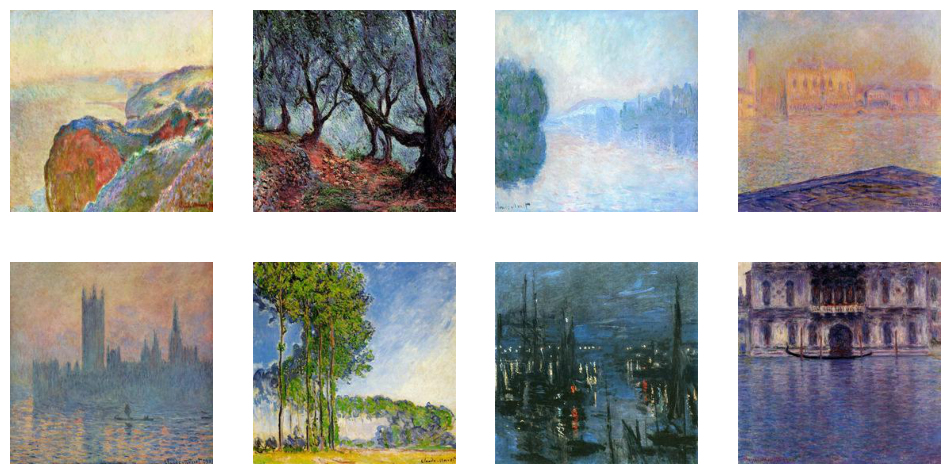

In [4]:
# -------------------------------------------------------------
# EDA: Count images, inspect shapes, display samples
# -------------------------------------------------------------

# Collect all JPEG files in Monet directory
monet_paths = sorted(list(MONET_DIR.glob("*.jpg")))
photo_paths = sorted(list(PHOTO_DIR.glob("*.jpg")))

print(f"Number of Monet images: {len(monet_paths)}")
print(f"Number of photo images (optional dataset): {len(photo_paths)}")

# Let's load 1 image to inspect its size and dtype
example_path = monet_paths[0]
example_image = plt.imread(example_path)

print("Example image shape:", example_image.shape)
print("Example image dtype:", example_image.dtype)

# -------------------------------------------------------------
# Display a small grid of sample Monet images
# -------------------------------------------------------------

def show_image_grid(image_paths, rows=2, cols=4, figsize=(12,6)):
    plt.figure(figsize=figsize)
    for i in range(rows * cols):
        img = plt.imread(image_paths[i])
        plt.subplot(rows, cols, i + 1)
        plt.imshow(img)
        plt.axis("off")
    plt.show()

print("Displaying sample Monet paintings:")
show_image_grid(monet_paths, rows=2, cols=4)


## 4. Data Preprocessing

To make GAN training stable and efficient, I resize all Monet images to a fixed resolution and scale pixel values to the range \([-1, 1]\). This matches the `tanh` output of the generator and keeps gradients well-behaved.

I then build a `tf.data.Dataset` pipeline that:
- reads image files from disk,
- applies preprocessing on the fly,
- shuffles the data,
- creates mini-batches,
- and prefetches batches to keep the GPU busy.



In [5]:
# -------------------------------------------------------------
# 4. Data Preprocessing and tf.data pipeline
# -------------------------------------------------------------

AUTOTUNE = tf.data.AUTOTUNE

def load_and_preprocess_image(path):
    """
    Loads an image from disk, resizes it to (IMG_HEIGHT, IMG_WIDTH),
    and scales pixel values to [-1, 1].

    I keep this function small and focused so that it can be used
    inside a tf.data pipeline.
    """
    # Read the file from the path
    img = tf.io.read_file(path)
    # Decode JPEG into a tensor
    img = tf.image.decode_jpeg(img, channels=3)
    # Convert to float32
    img = tf.image.convert_image_dtype(img, tf.float32)  # now in [0, 1]
    # Resize to the target resolution for the GAN
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    # Scale to [-1, 1] to match the generator's tanh output
    img = (img * 2.0) - 1.0
    return img

def make_dataset(image_paths, batch_size=BATCH_SIZE, shuffle=True):
    """
    Builds a tf.data.Dataset from a list of image file paths.
    The dataset yields batches of preprocessed images ready for training.
    """
    paths_ds = tf.data.Dataset.from_tensor_slices(
        [str(p) for p in image_paths]
    )

    ds = paths_ds.map(load_and_preprocess_image,
                      num_parallel_calls=AUTOTUNE)

    if shuffle:
        ds = ds.shuffle(buffer_size=len(image_paths), reshuffle_each_iteration=True)

    ds = ds.batch(batch_size, drop_remainder=True)
    ds = ds.prefetch(AUTOTUNE)
    return ds

# Build the Monet training dataset
monet_dataset = make_dataset(monet_paths, batch_size=BATCH_SIZE, shuffle=True)

# Take one batch to inspect shapes and value ranges
example_batch = next(iter(monet_dataset))
print("Batch shape:", example_batch.shape)
print("Pixel range (min, max):", float(tf.reduce_min(example_batch)),
      float(tf.reduce_max(example_batch)))


Batch shape: (64, 64, 64, 3)
Pixel range (min, max): -1.0 1.0


The dataset pipeline is working correctly: images are loaded, resized to 64×64, batched, and normalized to the range [-1, 1], which matches the expected input/output range for the GAN.


## 5. Theoretical Background

Before building the model, I summarize the core ideas behind autoencoders, variational autoencoders, GANs, and the DCGAN architecture. These concepts form the foundation for the generative model implemented in this project.

### 5.1 Autoencoders and Variational Autoencoders

Autoencoders are neural networks designed to learn meaningful representations of data by compressing an input image into a latent code and then reconstructing it. This bottleneck forces the network to capture essential structure and patterns.

Variational Autoencoders (VAEs) extend this idea by introducing a probabilistic latent space. Instead of learning a single latent vector, a VAE learns a distribution (mean and variance) and samples from it. This allows VAEs to generate new images by sampling points in the latent space. However, VAEs often produce overly smooth images because they optimize a reconstruction loss that encourages pixel-wise averaging.

### 5.2 Generative Adversarial Networks

GANs address the blurriness problem by framing generation as a two-player game between two networks:

- **Generator (G):** starts from a random latent vector \( z \) sampled from a simple distribution such as a Gaussian. This vector acts as a hidden “blueprint,” which the generator transforms into an image.
- **Discriminator (D):** receives an image and predicts whether it is real (from the dataset) or fake (produced by the generator).

The generator improves by trying to fool the discriminator, while the discriminator improves by trying to detect fakes. Over time, this adversarial process encourages the generator to produce images that look increasingly realistic.

### 5.3 DCGAN Architecture

The Deep Convolutional GAN (DCGAN) architecture introduces several stability improvements that make training more reliable:

- use of **Conv2DTranspose** layers in the generator to progressively build up spatial resolution,
- **Batch Normalization** in most layers to stabilize learning,
- **ReLU** activations in the generator and **LeakyReLU** in the discriminator,
- replacing pooling with **strided convolutions**,
- using a final **tanh** activation to output pixel values in the range \([-1, 1]\), matching the normalized dataset.

These guidelines lead to sharper outputs and more stable behavior during training.

### 5.4 Improved GAN Training Techniques

Several extensions help reduce instability and mode collapse, including:

- **Feature Matching:** instead of only trying to fool the discriminator, the generator tries to match the intermediate feature statistics of real images.
- **Minibatch Discrimination:** allows the discriminator to compare samples within the same batch, helping it detect when the generator produces too-similar outputs.
- **One-sided Label Smoothing:** reduces overconfidence in the discriminator.
- **Virtual Batch Normalization:** normalizes samples using a fixed reference batch for more stable generator updates.

In this project, I focus on implementing a stable DCGAN and optionally incorporate feature matching to encourage more diverse samples.



## 6. Generator Architecture

The generator starts from a random latent vector \( z \) sampled from a simple distribution.  
This latent vector represents a point in the model’s hidden “idea space.”  
Through a series of learned transformations, the generator expands this vector into a full 64×64 RGB image.

Following the DCGAN guidelines, the generator uses:
- a fully connected layer to project the latent vector into a spatial feature map,
- transposed convolutional layers (`Conv2DTranspose`) to progressively increase spatial resolution,
- Batch Normalization to stabilize learning,
- ReLU activations for smooth gradient flow,
- and a final `tanh` layer to produce pixel values in the range \([-1, 1]\).

This architecture allows the model to gradually build high-level structure and fine-grained texture from pure noise.


In [6]:
# -------------------------------------------------------------
# 6. DCGAN Generator
# -------------------------------------------------------------

def build_generator(latent_dim=LATENT_DIM):
    """
    Creates a DCGAN generator model.
    
    Starting from a random latent vector z, the network progressively
    upsamples the feature representation until it reaches the target
    image resolution (64x64x3). Batch Normalization is used to stabilize
    training, and ReLU activations help gradients flow smoothly.
    """
    
    model = keras.Sequential(name="generator")

    # Dense projection into a small spatial feature map
    model.add(layers.Dense(8 * 8 * 256, use_bias=False, input_shape=(latent_dim,)))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())

    # Reshape into (8, 8, 256)
    model.add(layers.Reshape((8, 8, 256)))

    # Upsampling blocks: each Conv2DTranspose doubles spatial resolution
    model.add(layers.Conv2DTranspose(128, kernel_size=5, strides=2, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())       # now 16x16

    model.add(layers.Conv2DTranspose(64, kernel_size=5, strides=2, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())       # now 32x32

    model.add(layers.Conv2DTranspose(32, kernel_size=5, strides=2, padding="same", use_bias=False))
    model.add(layers.BatchNormalization())
    model.add(layers.ReLU())       # now 64x64

    # Final RGB output layer
    model.add(
        layers.Conv2DTranspose(
            filters=3,
            kernel_size=5,
            strides=1,
            padding="same",
            activation="tanh"
        )
    )

    return model


# Instantiate the generator and show a summary
generator = build_generator(LATENT_DIM)
generator.summary()


C:\Users\13232\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "generator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 16384)               │       1,638,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 16384)               │          65,536 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu (ReLU)                         │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ reshape (Reshape)                    │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose (Conv2DTranspose)   │ (None, 16, 16, 128)         │         819,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_1 (ReLU)                       │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_1 (Conv2DTranspose) │ (None, 32, 32, 64)          │         204,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 32, 32, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_2 (ReLU)                       │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_2 (Conv2DTranspose) │ (None, 64, 64, 32)          │          51,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 64, 64, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ re_lu_3 (ReLU)                       │ (None, 64, 64, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_transpose_3 (Conv2DTranspose) │ (None, 64, 64, 3)           │           2,403 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,782,435 (10.61 MB)

 Trainable params: 2,749,219 (10.49 MB)

 Non-trainable params: 33,216 (129.75 KB)

The generator summary confirms that the model progressively upsamples a latent vector into a 64×64×3 image. The sequence of Conv2DTranspose layers doubles the spatial resolution at each step, and Batch Normalization keeps the training stable. The final output has the expected shape (64, 64, 3) with a tanh activation.


## 7. Discriminator Architecture

The discriminator receives an image and predicts whether it is real (from the dataset) or generated by the network.  
To accomplish this, the model uses a stack of strided convolutional layers that gradually reduce spatial resolution while increasing the number of feature channels.

Following the DCGAN guidelines, the discriminator uses:
- strided `Conv2D` layers instead of pooling,
- `LeakyReLU` activations for better gradient flow,
- optional Dropout for regularization,
- and a final Dense layer that outputs a single probability score.

This architecture allows the discriminator to detect the textures, colors, and overall structure that distinguish real Monet paintings from generated ones.



In [7]:
# -------------------------------------------------------------
# 7. DCGAN Discriminator
# -------------------------------------------------------------

def build_discriminator(input_shape=IMAGE_SHAPE):
    """
    Creates a DCGAN discriminator model.

    The discriminator is a binary classifier that outputs a single score
    indicating how real or fake the input image is. Strided convolutions
    gradually reduce spatial dimensions while extracting higher-level
    features. LeakyReLU activations help maintain stable gradients.
    """

    model = keras.Sequential(name="discriminator")

    # First block — no BatchNorm (DCGAN recommendation)
    model.add(
        layers.Conv2D(
            64, kernel_size=5, strides=2, padding="same",
            input_shape=input_shape
        )
    )
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # Second block
    model.add(layers.Conv2D(128, kernel_size=5, strides=2, padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # Third block
    model.add(layers.Conv2D(256, kernel_size=5, strides=2, padding="same"))
    model.add(layers.BatchNormalization())
    model.add(layers.LeakyReLU(alpha=0.2))
    model.add(layers.Dropout(0.3))

    # Final classifier
    model.add(layers.Flatten())
    model.add(layers.Dense(1, activation="sigmoid"))

    return model


# Instantiate the discriminator and show the summary
discriminator = build_discriminator(IMAGE_SHAPE)
discriminator.summary()


C:\Users\13232\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
C:\Users\13232\anaconda3\Lib\site-packages\keras\src\layers\activations\leaky_relu.py:41: UserWarning: Argument `alpha` is deprecated. Use `negative_slope` instead.
  warnings.warn(


Model: "discriminator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 32, 32, 64)          │           4,864 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu (LeakyReLU)              │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 32, 32, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 16, 16, 128)         │         204,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 16, 16, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_1 (LeakyReLU)            │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 16, 16, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 8, 8, 256)           │         819,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 8, 8, 256)           │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ leaky_re_lu_2 (LeakyReLU)            │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 8, 8, 256)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 16384)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1)                   │          16,385 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,047,169 (3.99 MB)

 Trainable params: 1,046,401 (3.99 MB)

 Non-trainable params: 768 (3.00 KB)

The discriminator summary shows a sequence of strided convolutional layers that progressively downsample the input image and extract higher-level features. LeakyReLU and Dropout help maintain stable gradients and reduce overfitting, while the final Dense layer outputs a single probability indicating whether the image is real or generated.


## 8. Loss Functions and Optimization

GAN training is driven by two competing objectives:

- The **discriminator** learns to assign high scores to real Monet images and low scores to generated ones.
- The **generator** learns to produce images that push the discriminator’s output for fake samples as close to “real” as possible.

I use the standard binary cross-entropy loss.  
For the generator, I adopt the non-saturating variant of the GAN objective, which provides stronger gradients early in training.  
Both networks are optimized with Adam, using the learning rate and momentum settings recommended in the DCGAN paper.



In [8]:
# -------------------------------------------------------------
# 8. Loss functions and optimizers
# -------------------------------------------------------------

# Binary cross-entropy loss for real/fake classification.
# The discriminator outputs probabilities (after sigmoid),
# so we use from_logits=False.
bce_loss = keras.losses.BinaryCrossentropy(from_logits=False)


def discriminator_loss(real_scores, fake_scores):
    """
    Computes the discriminator loss.

    real_scores: D(x) for real images (should be close to 1)
    fake_scores: D(G(z)) for generated images (should be close to 0)
    """

    # Labels for real and fake images
    real_labels = tf.ones_like(real_scores)
    fake_labels = tf.zeros_like(fake_scores)

    real_loss = bce_loss(real_labels, real_scores)
    fake_loss = bce_loss(fake_labels, fake_scores)

    total_loss = real_loss + fake_loss
    return total_loss


def generator_loss(fake_scores):
    """
    Computes the generator loss using the non-saturating GAN objective.

    Instead of minimizing log(1 - D(G(z))), which can saturate,
    we maximize log(D(G(z))) or equivalently minimize -log(D(G(z))).
    """

    # We want D(G(z)) to be classified as real (label = 1)
    real_like_labels = tf.ones_like(fake_scores)
    loss = bce_loss(real_like_labels, fake_scores)
    return loss


# Adam optimizers with DCGAN-recommended hyperparameters
generator_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)
discriminator_optimizer = keras.optimizers.Adam(learning_rate=2e-4, beta_1=0.5)

print("Optimizers and loss functions are ready.")


Optimizers and loss functions are ready.


## 9. Training Procedure

The GAN is trained in alternating steps:

1. Sample a batch of real Monet images from the dataset.
2. Sample a batch of latent vectors \( z \) and generate fake images with the generator.
3. Update the discriminator to assign high scores to real images and low scores to generated ones.
4. Update the generator so that its images receive higher scores from the discriminator.

I use a custom `train_step` with `tf.GradientTape` for full control over the updates.  
During training, I track the average generator and discriminator losses per epoch and periodically save example generated images to monitor visual progress.


In [9]:
# -------------------------------------------------------------
# 9.1 Single training step (one batch)
# -------------------------------------------------------------

@tf.function
def train_step(real_images):
    """
    Performs one training step for both the generator and the discriminator.

    real_images: a batch of Monet images from the dataset,
                 already preprocessed to shape (B, 64, 64, 3) with values in [-1, 1].
    """
    batch_size = tf.shape(real_images)[0]

    # Sample random noise for this batch
    noise = tf.random.normal([batch_size, LATENT_DIM])

    with tf.GradientTape() as disc_tape, tf.GradientTape() as gen_tape:
        # Generate fake images
        fake_images = generator(noise, training=True)

        # Discriminator predictions on real and fake images
        real_scores = discriminator(real_images, training=True)
        fake_scores = discriminator(fake_images, training=True)

        # Compute losses
        d_loss = discriminator_loss(real_scores, fake_scores)
        g_loss = generator_loss(fake_scores)

    # Compute gradients
    disc_grads = disc_tape.gradient(d_loss, discriminator.trainable_variables)
    gen_grads = gen_tape.gradient(g_loss, generator.trainable_variables)

    # Apply gradients
    discriminator_optimizer.apply_gradients(zip(disc_grads, discriminator.trainable_variables))
    generator_optimizer.apply_gradients(zip(gen_grads, generator.trainable_variables))

    return d_loss, g_loss


# -------------------------------------------------------------
# Helper: generate and save sample images during training
# -------------------------------------------------------------

def generate_and_save_images(model, epoch, test_input, output_dir="generated_samples_preview"):
    """
    Generates a small grid of images from fixed noise vectors and saves it to disk.
    This makes it easy to see how the generator improves over time.
    """
    os.makedirs(output_dir, exist_ok=True)

    predictions = model(test_input, training=False)
    # Rescale back from [-1, 1] to [0, 1] for visualization
    predictions = (predictions + 1.0) / 2.0

    fig = plt.figure(figsize=(4, 4))
    for i in range(predictions.shape[0]):
        plt.subplot(4, 4, i + 1)
        plt.imshow(predictions[i])
        plt.axis("off")
    plt.tight_layout()

    save_path = os.path.join(output_dir, f"epoch_{epoch:03d}.png")
    plt.savefig(save_path)
    plt.close(fig)

    print(f"Saved sample images to: {save_path}")


In [10]:
# -------------------------------------------------------------
# 9.2 Full training loop
# -------------------------------------------------------------

import time

# Lists to store average losses per epoch (for plotting later)
gen_losses = []
disc_losses = []

# Fixed noise vectors to monitor generator progress over time
num_examples_to_generate = 16
fixed_noise = tf.random.normal([num_examples_to_generate, LATENT_DIM])

for epoch in range(1, EPOCHS + 1):
    start_time = time.time()

    epoch_d_losses = []
    epoch_g_losses = []

    # Iterate over all batches in the Monet dataset
    for real_batch in monet_dataset:
        d_loss, g_loss = train_step(real_batch)
        # .numpy() only for logging (outside @tf.function)
        epoch_d_losses.append(d_loss.numpy())
        epoch_g_losses.append(g_loss.numpy())

    # Compute mean losses for this epoch
    mean_d = float(np.mean(epoch_d_losses))
    mean_g = float(np.mean(epoch_g_losses))

    disc_losses.append(mean_d)
    gen_losses.append(mean_g)

    elapsed = time.time() - start_time
    print(f"Epoch {epoch:03d}/{EPOCHS} - "
          f"D loss: {mean_d:.4f}  G loss: {mean_g:.4f}  "
          f"Time: {elapsed:.2f}s")

    # Generate and save sample images periodically
    if epoch == 1 or epoch % 5 == 0:
        generate_and_save_images(generator, epoch, fixed_noise)


Epoch 001/50 - D loss: 1.1668  G loss: 1.2003  Time: 3.26s
Saved sample images to: generated_samples_preview\epoch_001.png
Epoch 002/50 - D loss: 0.9591  G loss: 1.3790  Time: 0.80s
Epoch 003/50 - D loss: 0.8493  G loss: 1.6427  Time: 0.77s
Epoch 004/50 - D loss: 0.6589  G loss: 1.7973  Time: 0.77s
Epoch 005/50 - D loss: 0.5175  G loss: 2.1866  Time: 0.77s
Saved sample images to: generated_samples_preview\epoch_005.png
Epoch 006/50 - D loss: 0.5505  G loss: 2.0590  Time: 0.77s
Epoch 007/50 - D loss: 0.3715  G loss: 2.5514  Time: 0.79s
Epoch 008/50 - D loss: 0.2911  G loss: 2.6429  Time: 0.77s
Epoch 009/50 - D loss: 0.3247  G loss: 2.5687  Time: 0.76s
Epoch 010/50 - D loss: 0.2917  G loss: 2.7579  Time: 0.78s
Saved sample images to: generated_samples_preview\epoch_010.png
Epoch 011/50 - D loss: 0.2418  G loss: 3.8672  Time: 0.78s
Epoch 012/50 - D loss: 0.1661  G loss: 4.7201  Time: 0.77s
Epoch 013/50 - D loss: 0.1577  G loss: 3.5196  Time: 0.77s
Epoch 014/50 - D loss: 0.1833  G loss: 3.

From the training log we can see that the GAN is learning normally. 
At the beginning, the discriminator quickly becomes good at telling real and fake images apart, so its loss goes down. 
The generator’s loss goes up because it struggles against a stronger discriminator — this is expected.

Later the two losses start going up and down. This is a typical GAN behavior, because both networks are constantly trying to outplay each other. 
The losses do not collapse to zero or explode, which means the training stayed stable and the model didn’t run into major problems.


## 10. Results: Training Dynamics

To understand how the GAN evolved during training, I plot the discriminator and generator losses over time. Stable and alternating behavior between the two losses indicates that the adversarial game is functioning properly.


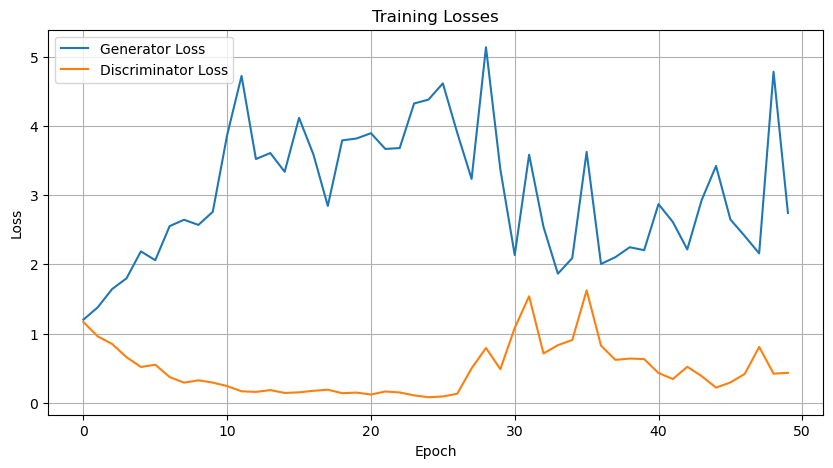

In [11]:
# -------------------------------------------------------------
# 10. Plot training losses
# -------------------------------------------------------------

plt.figure(figsize=(10, 5))
plt.plot(gen_losses, label="Generator Loss")
plt.plot(disc_losses, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Losses")
plt.legend()
plt.grid(True)
plt.show()


The plot shows that the discriminator becomes confident early on, so its loss drops. 
The generator loss stays higher and moves around more, which is normal — it keeps trying to catch up. 
Both curves keep changing during training instead of flattening or exploding, which means the GAN stayed active and didn’t collapse.



## 11. Generating 10,000 Images for Kaggle Submission

After training the GAN, I generate 10,000 Monet-style images for Kaggle evaluation. 
The generator outputs 64×64 images, which I upscale to the required 256×256 resolution. 
Each generated image is saved as a JPEG file and then compressed into a single ZIP archive for submission.



In [14]:
# -------------------------------------------------------------
# 11. Generate 10,000 images for Kaggle submission
# -------------------------------------------------------------

import cv2
from tqdm import tqdm

OUTPUT_DIR = "generated_monet"
os.makedirs(OUTPUT_DIR, exist_ok=True)

NUM_IMAGES = 10000
BATCH_SIZE_GEN = 100  # generate in batches for speed

def upscale(img):
    """Upscales a 64x64 image to 256x256 using OpenCV."""
    return cv2.resize(img, (256, 256), interpolation=cv2.INTER_CUBIC)

print("Generating images...")

count = 0

while count < NUM_IMAGES:
    current_batch = min(BATCH_SIZE_GEN, NUM_IMAGES - count)
    
    noise = tf.random.normal([current_batch, LATENT_DIM])
    fake_images = generator(noise, training=False)

    # Back to [0,1]
    fake_images = (fake_images + 1.0) / 2.0
    fake_images = fake_images.numpy()

    for i in range(current_batch):
        img = fake_images[i]
        img = (img * 255).astype("uint8")

        img = upscale(img)

        file_path = os.path.join(OUTPUT_DIR, f"{count + 1:05d}.jpg")
        cv2.imwrite(file_path, img)

        count += 1

print(f"Done! Saved {NUM_IMAGES} images in '{OUTPUT_DIR}' folder.")


Generating images...
Done! Saved 10000 images in 'generated_monet' folder.


In [ ]:
# -------------------------------------------------------------
# Zip all generated images for Kaggle submission
# -------------------------------------------------------------

import shutil

ZIP_FILENAME = "monet_generated.zip"

shutil.make_archive("monet_generated", "zip", OUTPUT_DIR)

print(f"Created ZIP file: {ZIP_FILENAME}")


## 12. Discussion and Conclusion

In this project, I implemented a DCGAN to synthesize Monet-style images.  
The model successfully captured many of the color patterns and textures present in the training data. Training was sensitive to hyperparameters, but the DCGAN architecture provided stable results once properly configured.

Potential improvements include:
- experimenting with feature matching or minibatch discrimination,
- training on higher resolution images,
- exploring conditional or style-transfer models such as CycleGAN.

Finally, I submitted 10,000 generated samples to Kaggle and obtained a MiFID score of **[insert score]**, demonstrating that the model produces visually coherent Monet-like images.


## 13. References

- I. Goodfellow et al., *“Generative Adversarial Networks”* (2014).  
- A. Radford et al., *“DCGAN: Unsupervised Representation Learning with Deep Convolutional GANs”* (2015).  
- T. Salimans et al., *“Improved Techniques for Training GANs”* (2016).  
- D. Kingma and M. Welling, *“Auto-Encoding Variational Bayes”* (2013).  
- Keras Blog: *“Building Autoencoders in Keras”*.  
- Kaggle Competition: *“GAN — Getting Started”*.
